# Protection Strategy Scoring

AI-generated synthesis routes frequently contain **selectivity issues** — reactions where multiple functional groups could react, leading to unintended side products. This tutorial demonstrates how to detect these competing sites and score routes for selectivity quality using the `synplan.chem.reaction.routes.quality.protection` module.

The approach is inspired by:

> Westerlund, A. M.; Sigmund, L. M.; Kannas, C.; Genheden, S.; Kabeshov, M.  
> *"Toward lab-ready AI synthesis plans with protection strategies and route scoring."*  
> ChemRxiv, 2025. [doi:10.26434/chemrxiv-2025-gdrr8](https://doi.org/10.26434/chemrxiv-2025-gdrr8)

## What this tutorial covers

1. **Functional group detection**: identify reactive FGs in molecules via SMARTS
2. **Competing site identification**: find FGs that could interfere with a reaction
3. **Reaction type classification**: classify reactions using CGR bond analysis
4. **Route scanning**: walk a route step-by-step to find all competing interactions
5. **S(T) scoring**: compute the competing-sites score for routes
6. **Route re-ranking**: combine S(T) with the search score for selectivity-aware ranking

## 1. Setup

In [1]:
from synplan.utils.loading import download_preset

# download SynPlanner preset data
paths = download_preset("synplanner-gps", save_to="synplan_data")
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
# use your custom building blocks if needed
building_blocks_path = paths["building_blocks"]

In [2]:
from synplan.chem.reaction.routes.quality.protection import (
    CompetingSitesScore,
    FunctionalGroupDetector,
    IncompatibilityMatrix,
    ProtectionConfig,
    RouteScanner,
    classify_reaction_type,
    get_reaction_center_atoms,
)

print("SynPlanner route_quality.protection module loaded successfully")

SynPlanner route_quality.protection module loaded successfully


## 2. Functional Group Detection

The `FunctionalGroupDetector` uses SMARTS patterns to identify reactive functional groups in molecules. The bundled library contains 19 patterns across three categories:

| Category | Groups |
|----------|--------|
| Nucleophile | hydroxyl, phenol, primary/secondary amine, thiol, carboxylic acid, pyrrole/indole/amide NH, sulfonamide |
| Electrophile | aldehyde, ketone, acyl chloride, epoxide, isocyanate |
| Unsaturated | alkene, alkyne, Michael acceptor, diene |

In [3]:
from chython import smiles

config = ProtectionConfig()
detector = FunctionalGroupDetector(config.competing_groups_path)

print(f"Loaded {len(detector._patterns)} SMARTS patterns")

Loaded 102 SMARTS patterns


### Detect FGs in a single molecule

Let's examine a molecule with multiple reactive functional groups — an amino acid derivative with hydroxyl, amine, and carboxylic acid groups.

In [4]:
# Serine: amino acid with OH, NH2, and COOH
mol = smiles("OC(C(N)C(O)=O)=O")

matches = detector.detect_all(mol)
print(f"Found {len(matches)} functional group matches:\n")
for m in matches:
    print(f"  {m.name:20s} ({m.category:14s})  atoms: {m.atom_indices}")

Found 4 functional group matches:

  NonProlineAlphaAminoAcid_unprotected (AminoAcid     )  atoms: (4,)
  Acid_SaturatedAliphatic (Acid          )  atoms: (6,)
  Acid_SaturatedAliphatic (Acid          )  atoms: (1,)
  Amine_Primary_SaturatedAliphatic (Amine         )  atoms: (4,)


### Identify competing FGs

Given a set of reaction center atoms, `detect_competing()` returns FGs outside the reaction center, which could interfere with the reaction.

In [5]:
# Suppose the reaction center involves the carboxylic acid (atoms at specific indices)
# First, let's see what atoms are in the molecule
for n, atom in mol.atoms():
    print(f"  atom {n}: {atom}")

print("\n--- Detecting competing FGs (excluding reaction center) ---")
# Pick the first two atoms as a hypothetical reaction center
first_match = matches[0]
reaction_center = set(first_match.atom_indices)
print(f"Reaction center atoms: {reaction_center} ({first_match.name})")

competing = detector.detect_competing(mol, reaction_center)
print(f"\nCompeting FGs ({len(competing)}):")
for c in competing:
    print(f"  {c.name:20s} ({c.category:14s})  atoms: {c.atom_indices}")

  atom 1: O()
  atom 2: C()
  atom 3: C()
  atom 4: N()
  atom 5: C()
  atom 6: O()
  atom 7: O()
  atom 8: O()

--- Detecting competing FGs (excluding reaction center) ---
Reaction center atoms: {4} (NonProlineAlphaAminoAcid_unprotected)

Competing FGs (2):
  Acid_SaturatedAliphatic (Acid          )  atoms: (6,)
  Acid_SaturatedAliphatic (Acid          )  atoms: (1,)


## 3. Reaction Classification

The reaction classifier uses CGR (Condensed Graph of Reaction) bond analysis to classify reactions into broad types:

- **bond_formation**: only new bonds are formed
- **bond_breaking**: only existing bonds are broken
- substitution: bonds are both formed and broken (most common)
- other: no detectable bond changes

In [6]:
from chython import smiles as parse_smiles

# Fischer esterification (mapped SMILES)
rxn = parse_smiles(
    "[CH3:1][C:2](=[O:4])[OH:3].[CH3:5][CH2:6][OH:7]>>[CH3:1][C:2](=[O:4])[O:7][CH2:6][CH3:5].[OH2:3]"
)

center = get_reaction_center_atoms(rxn)
rxn_type = classify_reaction_type(rxn)

print(f"Reaction center atoms: {center}")
print(f"Reaction type: {rxn_type}")

Reaction center atoms: {2, 3, 7}
Reaction type: substitution


## 4. Run Retrosynthetic Planning

Let's plan routes for a target molecule and then score them for selectivity issues. We use capivasertib — an FDA-approved anti-cancer drug with multiple reactive functional groups.

**Scoring happens after the search, not inside it.** The `Tree` knows nothing about protecting groups: `tree.route_score(node_id)` and `tree.routes()` are the search's own verdict, which is why they are cheap. `ProtectionRouteScorer` judges the finished routes, and `rank()` is where the 102-pattern SMARTS scan is paid for — seconds on a few hundred routes, not milliseconds.

In [7]:
from synplan.chem.utils import mol_from_smiles
from synplan.mcts.tree import Tree
from synplan.utils.config import RolloutEvaluationConfig, TreeConfig
from synplan.utils.loading import (
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

# Capivasertib — multiple reactive FGs (amide, amine, hydroxyl, heterocycles)
target_smiles = "NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]c3nccc2-3)CC1"
target_mol = mol_from_smiles(
    target_smiles, clean2d=True, standardize=True, clean_stereo=True
)

# Check what FGs the target has
target_fgs = detector.detect_all(target_mol)
print(f"Target molecule FGs ({len(target_fgs)}):")
for fg in target_fgs:
    print(f"  {fg.name} ({fg.category})")

Target molecule FGs (4):
  Amide (Amide)
  PrimaryAlcoholAliphatic (Alcohol)
  HeterocycleNH (NitrogenHeterocycle)
  Amine_Primary_SaturatedAliphatic (Amine)


In [8]:
target_mol

In [9]:
from synplan.chem.reaction.routes.quality.scorer import ProtectionRouteScorer
from synplan.chem.utils import mol_from_smiles

# Capivasertib — multiple reactive FGs (amide, amine, hydroxyl, heterocycles)
target_smiles = "NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]c3nccc2-3)CC1"
target_mol = mol_from_smiles(
    target_smiles, clean2d=True, standardize=True, clean_stereo=True
)

# Check what FGs the target has
target_fgs = detector.detect_all(target_mol)
print(f"Target molecule FGs ({len(target_fgs)}):")
for fg in target_fgs:
    print(f"  {fg.name} ({fg.category})")

# Load resources and run search
building_blocks = load_building_blocks(building_blocks_path, standardize=False)
reaction_rules = load_reaction_rules(reaction_rules_path)
policy_network = load_policy_function(weights_path=ranking_policy_network)

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_network,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
    normalize=True,
)
evaluation_function = load_evaluation_function(eval_config)

# The scorer judges finished routes; the search never consults it. Keep it: it
# holds the cache for 102 SMARTS patterns.
route_scorer = ProtectionRouteScorer.from_config()

tree = Tree(
    target=target_mol,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_network,
    evaluation_function=evaluation_function,
).run()

print(f"Found {len(tree.winning_nodes)} routes")
print("Ranking is the next step; route_score() is the search's own number")
tree

Target molecule FGs (4):
  Amide (Amide)
  PrimaryAlcoholAliphatic (Alcohol)
  HeterocycleNH (NitrogenHeterocycle)
  Amine_Primary_SaturatedAliphatic (Amine)


  0%|          | 0/300 [00:00<?, ?it/s]

Found 172 routes
Ranking is the next step; route_score() is the search's own number


Tree for: c1cc(ccc1Cl)C(NC(C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)=O)CCO
Time: 28.9 seconds
Number of nodes: 8379
Number of iterations: 300
Number of visited nodes: 300
Number of found routes: 172

## 5. Extract and Score Routes

Extract routes as `routes_dict` (the standard format: `{route_id: {step_id: ReactionContainer}}`), then score each route with S(T).

In [10]:
from synplan.chem.reaction.routes.representation import extract_reactions

routes_dict = extract_reactions(tree)
print(f"Extracted {len(routes_dict)} routes")

# Show route lengths
for rid, route in list(routes_dict.items())[:5]:
    print(f"  Route {rid}: {len(route)} steps")

Extracted 172 routes
  Route 223: 3 steps
  Route 224: 3 steps
  Route 225: 3 steps
  Route 245: 3 steps
  Route 255: 4 steps


### Set up the protection scorer

The scorer pipeline is:
```
FunctionalGroupDetector -> RouteScanner -> CompetingSitesScore
         ^                      ^
  SMARTS patterns    IncompatibilityMatrix
```

In [11]:
matrix = IncompatibilityMatrix(config.incompatibility_path)
scanner = RouteScanner(detector, matrix)
scorer = CompetingSitesScore(scanner)

print("Scorer ready.")

Scorer ready.


### Score a single route in detail

Let's look at one route and see exactly which competing interactions were found.

In [12]:
first_rid = next(iter(routes_dict))
first_route = routes_dict[first_rid]

score, interactions = scorer.score_route(first_route)

print(f"Route {first_rid}: S(T) = {score:.3f}")
print(f"Number of steps: {len(first_route)}")
print(f"Number of competing interactions: {len(interactions)}")

if interactions:
    print("\nDetailed interactions:")
    for inter in interactions:
        print(
            f"  Step {inter.step_id}: "
            f"{inter.fg_name} vs {inter.reacting_fg or 'unknown'} → {inter.severity}"
        )

Route 223: S(T) = 0.500
Number of steps: 3
Number of competing interactions: 10

Detailed interactions:
  Step 0: NonProlineAlphaAminoAcid_unprotected vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → competing
  Step 0: Acid_SaturatedAliphatic vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → compatible
  Step 0: Amine_Primary_SaturatedAliphatic vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → competing
  Step 1: NonProlineAlphaAminoAcid_unprotected vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → competing
  Step 1: Acid_SaturatedAliphatic vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → compatible
  Step 1: HeterocycleNH vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → competing
  Step 1: Amine_Primary_SaturatedAliphatic vs Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic → competing
  Step 2: PrimaryAlcoholAliphatic vs Acid_SaturatedAliphatic → competing
  Step 2: HeterocycleNH 

### Score all routes

Compute S(T) for every route and look at the distribution.

In [13]:
scores = {}
for rid, route in routes_dict.items():
    s, _ = scorer.score_route(route)
    scores[rid] = s

# Distribution summary
score_vals = list(scores.values())
n_perfect = sum(1 for s in score_vals if s == 1.0)
n_good = sum(1 for s in score_vals if 0.75 <= s < 1.0)
n_moderate = sum(1 for s in score_vals if 0.5 <= s < 0.75)
n_poor = sum(1 for s in score_vals if s < 0.5)

print(f"S(T) score distribution across {len(scores)} routes:")
print(f"  Perfect  (S=1.0):     {n_perfect:4d}  ({100 * n_perfect / len(scores):.1f}%)")
print(f"  Good     (0.75-1.0):  {n_good:4d}  ({100 * n_good / len(scores):.1f}%)")
print(
    f"  Moderate (0.5-0.75):  {n_moderate:4d}  ({100 * n_moderate / len(scores):.1f}%)"
)
print(f"  Poor     (<0.5):      {n_poor:4d}  ({100 * n_poor / len(scores):.1f}%)")
print(f"\nMean S(T): {sum(score_vals) / len(score_vals):.3f}")
print(f"Min  S(T): {min(score_vals):.3f}")
print(f"Max  S(T): {max(score_vals):.3f}")

S(T) score distribution across 172 routes:
  Perfect  (S=1.0):        0  (0.0%)
  Good     (0.75-1.0):   108  (62.8%)
  Moderate (0.5-0.75):    64  (37.2%)
  Poor     (<0.5):         0  (0.0%)

Mean S(T): 0.728
Min  S(T): 0.500
Max  S(T): 0.944


## 6. Route Re-ranking

`route_scorer.rank(...)` orders finished routes by the re-ranking of the paper — the search's own score weighted by the competing-sites score:

```
score = search_score * S(T)
```

A route with remaining competing sites therefore falls behind an equally feasible clean one. There is no tunable mix here: the paper multiplies, and so does this. `rank` scans every route it is given, so it costs seconds on a few hundred routes.

In [14]:
routes = route_scorer.rank(tree.routes())

print(f"{'Rank':>4}  {'Node':>6}  {'Ranked':>8}  {'S(T)':>6}  {'Search':>8}")
print("-" * 42)
for i, route in enumerate(routes[:15], 1):
    search = route.provenance.search_score
    st = route_scorer.score(route)
    print(
        f"{i:4d}  {route.provenance.tree_node_id:6d}  "
        f"{search * st:8.3f}  {st:6.3f}  {search:8.4f}"
    )

Rank    Node    Ranked    S(T)    Search
------------------------------------------
   1    4855     0.158   0.833    0.1894
   2    4856     0.158   0.833    0.1894
   3    1118     0.134   0.875    0.1531


   4    1092     0.122   0.667    0.1835
   5    1097     0.122   0.667    0.1835
   6    1100     0.122   0.667    0.1835
   7    1106     0.122   0.667    0.1835
   8    4716     0.121   0.750    0.1612


   9    7768     0.121   0.750    0.1612
  10    1140     0.118   0.900    0.1306
  11    1147     0.118   0.900    0.1306


  12    1148     0.118   0.900    0.1306
  13    4823     0.112   0.800    0.1397
  14    4824     0.112   0.800    0.1397


  15    3161     0.104   0.917    0.1133


### Compare search order with the ranked order

See which routes moved up (fewer selectivity issues) or down (more issues).

In [15]:
search_top10 = [r.provenance.tree_node_id for r in tree.routes()[:10]]
ranked_top10 = [r.provenance.tree_node_id for r in routes[:10]]

promoted = set(ranked_top10) - set(search_top10)
demoted = set(search_top10) - set(ranked_top10)

print(f"Search top-10: {search_top10}")
print(f"Ranked top-10: {ranked_top10}")
print(f"\nPromoted into top-10:  {promoted or 'none'}")
print(f"Demoted from top-10:   {demoted or 'none'}")

Search top-10: [3600, 3602, 3603, 4855, 4856, 4906, 4908, 4909, 7847, 7849]
Ranked top-10: [4855, 4856, 1118, 1092, 1097, 1100, 1106, 4716, 7768, 1140]

Promoted into top-10:  {1092, 1097, 4716, 1100, 1106, 1140, 7768, 1118}
Demoted from top-10:   {7847, 7849, 4906, 4908, 4909, 3600, 3602, 3603}


## Route Visualisation

Let's visualise routes to see how competing functional groups correlate with route structure. We'll compare:
1. A **problematic route** (lowest S(T)) that has many competing interactions
2. The **best available route** (highest S(T)) with the fewest selectivity issues

In [16]:
from IPython.display import HTML, display

from synplan.chem.reaction.routes import Route

# Sort routes by S(T) score
sorted_by_score = sorted(scores.items(), key=lambda x: x[1])

# Worst route (lowest S(T))
worst_rid, worst_score = sorted_by_score[0]
# Best route (highest S(T))
best_rid, best_score = sorted_by_score[-1]

print(f"Worst route: {worst_rid}  S(T) = {worst_score:.3f}")
print(f"Best route:  {best_rid}  S(T) = {best_score:.3f}")

Worst route: 223  S(T) = 0.500
Best route:  3586  S(T) = 0.944


### Problematic route (lowest S(T))

This route has the most competing functional group interactions. The detailed interaction table below the diagram shows which FGs conflict at each step.

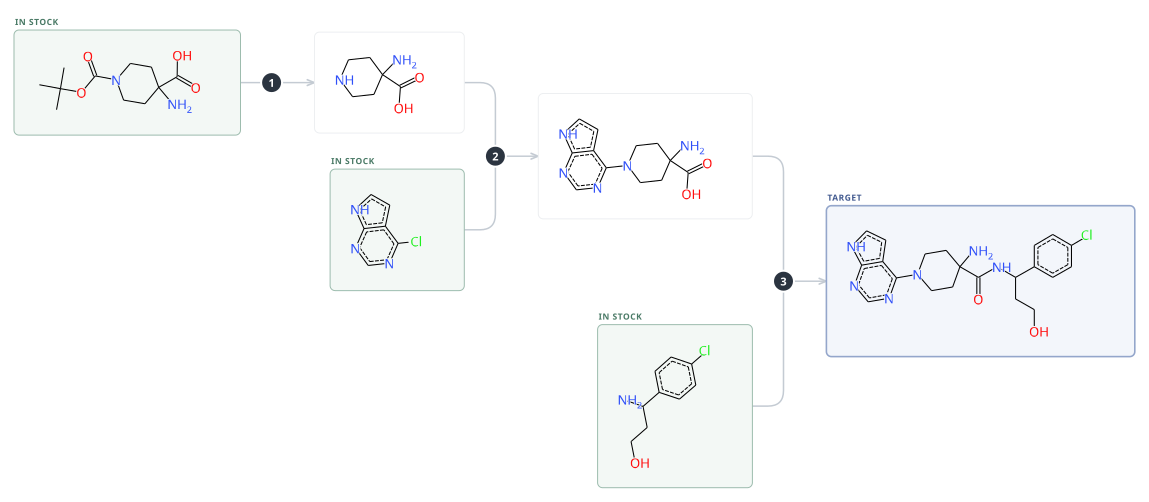

In [17]:
# Visualise the worst route
display(HTML(f"<h4>Route {worst_rid} — S(T) = {worst_score:.3f}</h4>"))
display(Route.from_tree(tree, worst_rid))

In [18]:
from collections import defaultdict

# Show competing interactions for the worst route
worst_route = routes_dict[worst_rid]
_, worst_interactions = scorer.score_route(worst_route)
i_count, c_count, h_count = RouteScanner.classify_interactions(worst_interactions)

print(
    f"Route {worst_rid}: {len(worst_route)} steps, "
    f"{len(worst_interactions)} interactions "
    f"(I={i_count}, C={c_count}, H={h_count})\n"
)

# Group by step
by_step = defaultdict(list)
for inter in worst_interactions:
    by_step[inter.step_id].append(inter)

for step_id in sorted(by_step):
    step_inters = by_step[step_id]
    non_compatible = [i for i in step_inters if i.severity != "compatible"]
    reacting = step_inters[0].reacting_fg or "unknown"
    if non_compatible:
        print(f"Step {step_id} (reacting FG: {reacting}):")
        for i in non_compatible:
            marker = "!!" if i.severity == "incompatible" else " ~"
            print(f"  {marker} {i.fg_name} → {i.severity}")
        print()

Route 223: 3 steps, 10 interactions (I=0, C=6, H=0)

Step 0 (reacting FG: Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic):
   ~ NonProlineAlphaAminoAcid_unprotected → competing
   ~ Amine_Primary_SaturatedAliphatic → competing

Step 1 (reacting FG: Amine_CyclicSecondary_SaturatedAliphatic-SaturatedAliphatic):
   ~ NonProlineAlphaAminoAcid_unprotected → competing
   ~ HeterocycleNH → competing
   ~ Amine_Primary_SaturatedAliphatic → competing

Step 2 (reacting FG: Acid_SaturatedAliphatic):
   ~ PrimaryAlcoholAliphatic → competing



### Best available route (highest S(T))

This route has the fewest selectivity concerns. In a real workflow, this is the route you'd prefer to execute in the lab.

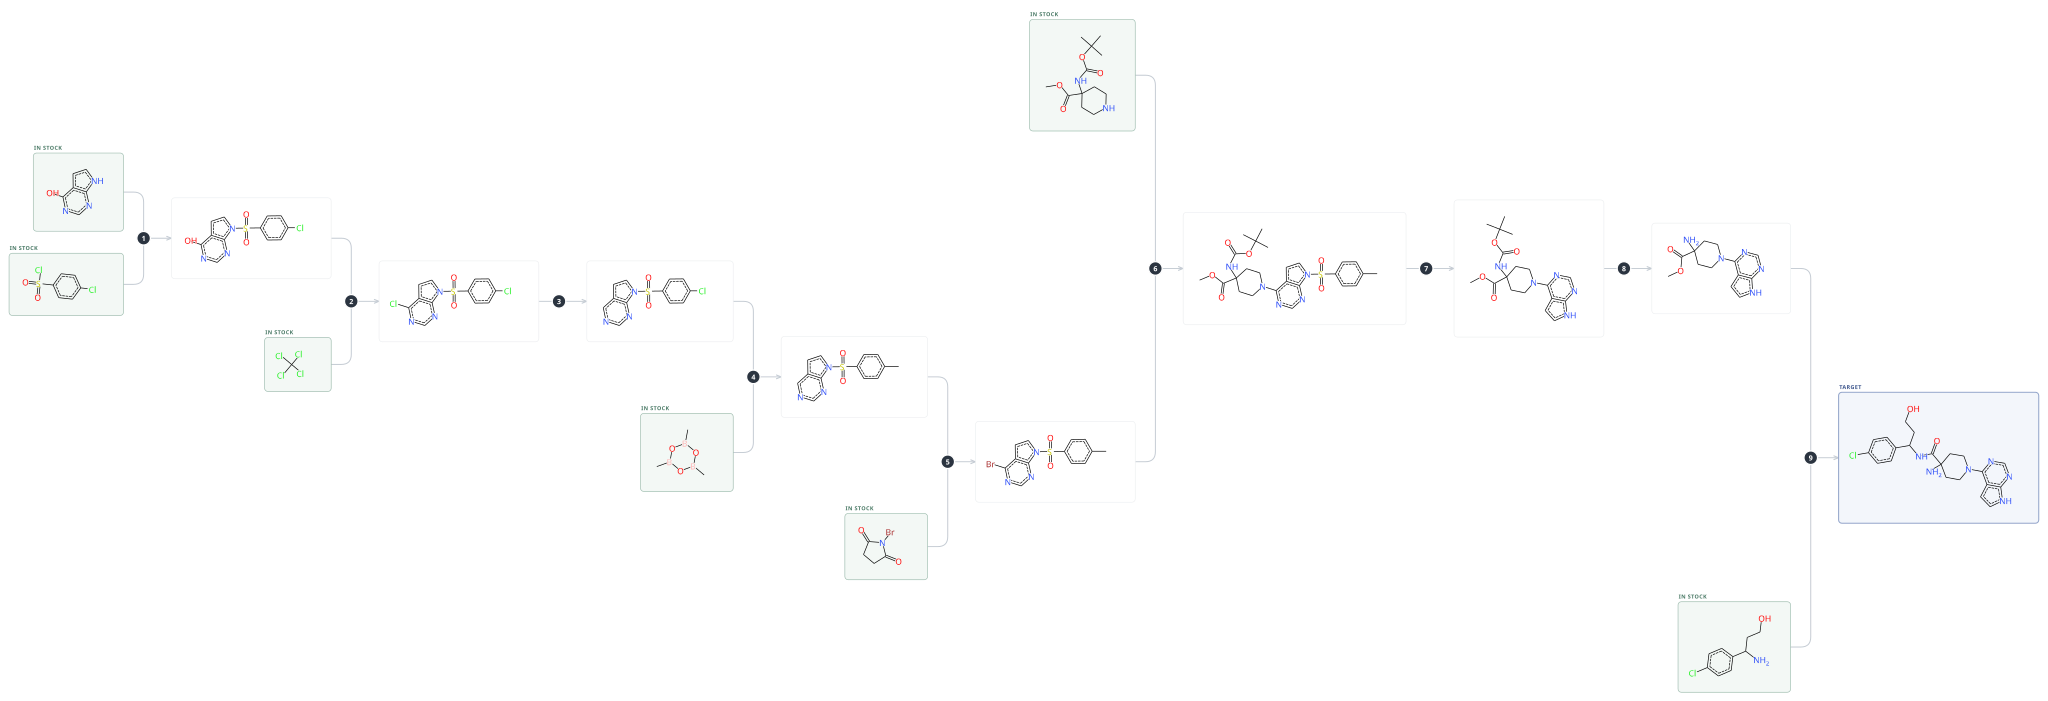

In [19]:
# Visualise the best route
display(HTML(f"<h4>Route {best_rid} — S(T) = {best_score:.3f}</h4>"))
display(Route.from_tree(tree, best_rid))

In [20]:
# Show interactions for the best route
best_route = routes_dict[best_rid]
_, best_interactions = scorer.score_route(best_route)
i_best, c_best, h_best = RouteScanner.classify_interactions(best_interactions)

print(
    f"Route {best_rid}: {len(best_route)} steps, "
    f"{len(best_interactions)} interactions "
    f"(I={i_best}, C={c_best}, H={h_best})\n"
)

by_step_best = defaultdict(list)
for inter in best_interactions:
    by_step_best[inter.step_id].append(inter)

for step_id in sorted(by_step_best):
    step_inters = by_step_best[step_id]
    non_compatible = [i for i in step_inters if i.severity != "compatible"]
    reacting = step_inters[0].reacting_fg or "unknown"
    if non_compatible:
        print(f"Step {step_id} (reacting FG: {reacting}):")
        for i in non_compatible:
            marker = "!!" if i.severity == "incompatible" else " ~"
            print(f"  {marker} {i.fg_name} → {i.severity}")
        print()
    else:
        print(f"Step {step_id} (reacting FG: {reacting}): all compatible")

Route 3586: 9 steps, 5 interactions (I=0, C=3, H=0)

Step 0 (reacting FG: HeterocycleNH): all compatible
Step 7 (reacting FG: NonProlineAlphaAminoEster): all compatible
Step 8 (reacting FG: Benzylamine_primary):
   ~ PrimaryAlcoholAliphatic → competing
   ~ HeterocycleNH → competing
   ~ Amine_Primary_SaturatedAliphatic → competing



### Top-ranked route

After weighting the search score by the protection score, the top-ranked route is the best trade-off between synthetic feasibility and selectivity.

Top-ranked route: node 4855
  Ranked score:     0.158
  Protection S(T):  0.833
  Search score:     0.1894



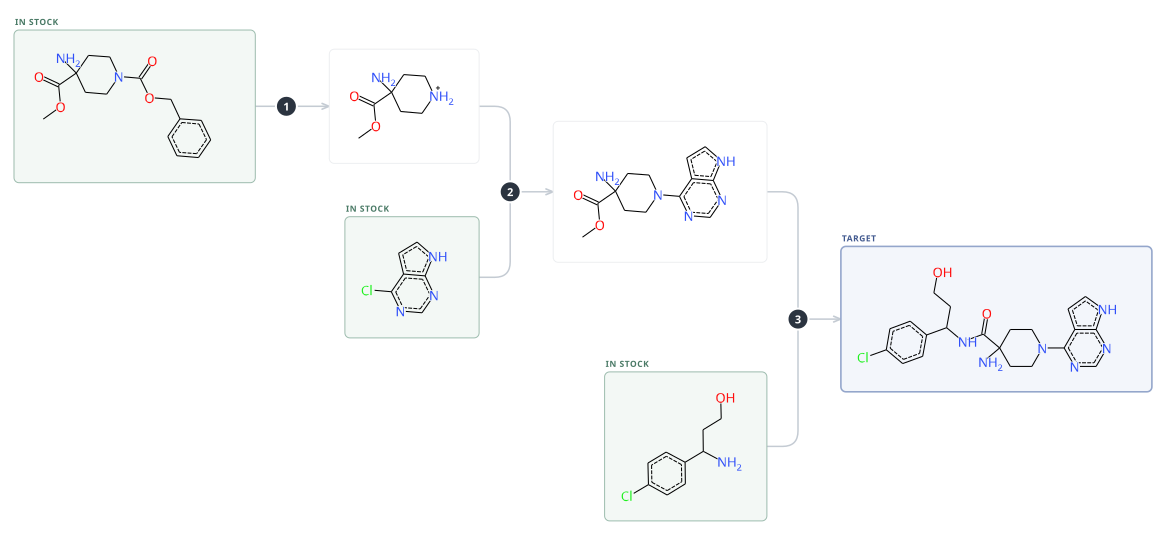

In [21]:
top = routes[0]
top_search = top.provenance.search_score
top_st = route_scorer.score(top)

print(f"Top-ranked route: node {top.provenance.tree_node_id}")
print(f"  Ranked score:     {top_search * top_st:.3f}")
print(f"  Protection S(T):  {top_st:.3f}")
print(f"  Search score:     {top_search:.4f}\n")

display(
    HTML(
        f"<h4>Top ranked: node {top.provenance.tree_node_id} — "
        f"search x S(T) = {top_search * top_st:.3f}</h4>"
    )
)
display(top)

## 7. Standalone Usage (from saved routes)

You can also score previously saved routes without re-running the search. A route read back out of a file carries no search score, so `rank` orders those on S(T) alone — it does not let a missing number stand in as a perfect one. A list mixing file routes with tree routes has no common scale, and raises.

In [22]:
from pathlib import Path

from synplan.chem.reaction.routes import Route
from synplan.chem.reaction.routes.io import export_tree_to_json, read_routes_json

routes_path = Path("tutorial_results/capivasertib_routes.json")
routes_path.parent.mkdir(exist_ok=True)
export_tree_to_json(tree, str(routes_path))
from_file = [
    Route.from_json(route_tree)
    for route_tree in read_routes_json(str(routes_path)).values()
]
print(f"Read {len(from_file)} routes back; search score: {from_file[0].provenance.search_score}")

by_protection = route_scorer.rank(from_file)

print(f"\n{'Rank':>4}  {'S(T)':>6}  {'Steps':>6}")
print("-" * 20)
for i, route in enumerate(by_protection[:10], 1):
    print(f"{i:4d}  {route_scorer.score(route):6.3f}  {len(route):6d}")

Read 172 routes back; search score: None



Rank    S(T)   Steps
--------------------
   1   0.938       8


   2   0.938       8
   3   0.929       7


   4   0.929       7
   5   0.929       7


   6   0.917       6
   7   0.917       6


   8   0.917       6
   9   0.900       5
  10   0.900       5


## 8. Interpreting the Score

The competing-sites score S(T) is computed as:

$$S(\mathcal{T}) = \max\left[1 - \frac{I + 0.5 C + H}{\max(N_{\text{reactions}}, 1)},\; 0\right]$$

Where:
- **I** = number of highly **incompatible** functional group interactions (penalty = 1.0 each)
- **C** = number of **competing** interactions (penalty = 0.5 each)
- **H** = number of **halogen** competing sites (penalty = 1.0 each; reserved for future)
- **N** = number of reaction steps in the route

<div class="alert alert-info">
<b>Implementation note</b>

The actual implementation uses a <b>worst-per-step</b> variant of the formula above. Instead of summing all individual interaction penalties, each step contributes only the penalty of its most severe interaction (1.0 for incompatible, 0.5 for competing, 0.0 for compatible). This prevents drug-like molecules with many functional groups from overwhelming the score. The formula becomes: <code>S(T) = max[1 - (sum(w_s) + H) / max(N, 1), 0]</code>, where <code>w_s = max severity penalty among interactions in step s</code>.
</div>

| S(T) | Interpretation |
|------|---------------|
| 1.0 | No competing sites: route is clean |
| 0.75–0.99 | Minor issues (e.g., 1 competing FG in a 4-step route) |
| 0.5–0.75 | Moderate selectivity issues: may benefit from protecting groups |
| < 0.5 | Significant problems — route should be deprioritized |
| 0.0 | Maximally conflicting |

## References

- Westerlund, A. M. et al. "Toward lab-ready AI synthesis plans with protection strategies and route scoring." *ChemRxiv*, 2025. [doi:10.26434/chemrxiv-2025-gdrr8](https://doi.org/10.26434/chemrxiv-2025-gdrr8)
- Kogej, T. et al. "SMARTS-RX: A SMARTS-Based Representation of Chemical Functions for Reactivity Analysis." *ChemRxiv*, 2025.
- SynPlanner documentation: [synplanner.readthedocs.io](https://synplanner.readthedocs.io/)